# Assignment 2 — Variational Autoencoder (VAE) on MNIST

**Student Name:** `Gandla Akshay Kumar`  
**Student ID:** `REDACTED`  

---

## Marking Structure (6 criteria, 100 marks)
1. **Setup & Data Pipeline** — 10  
2. **Model Architecture (Encoder/Decoder Design)** — 20  
3. **VAE-Specific Components & Loss Construction** — 25  
4. **Training Loop & Logging** — 15  
5. **Required Results & Visualisations** — 15  
6. **Notebook Report: Justification & Analysis** — 15  

> **Reminder:** Flexibility is allowed in architecture and training strategies, but **you must implement VAE-specific components yourself** (μ/logvar, reparameterisation, KL term).

---

## Quick Submission Checklist (run before submitting)
- [ ] **Kernel → Restart & Run All** completes with no errors  
- [ ] Output includes: reconstructions, random samples (8×8), interpolation (≥10 steps), training curves  
- [ ] Logs show **total / recon / KL** per epoch for **≥10 epochs**  
- [ ] Notebook includes **design justification and analysis** (Markdown)  
- [ ] File name follows the required format: `<id>_<name>_A2.ipynb`


## 1) Setup & Data Pipeline (10 marks)

### What you need to show
- Correct MNIST loading and **train/test split**
- Appropriate preprocessing (e.g., scale to **[0,1]**)
- DataLoader/batching
- Code runs on CPU (GPU optional)

### Evidence (tick when done)
- [ ] MNIST loaded correctly  
- [ ] Preprocessing explained (1–2 sentences)  
- [ ] Train/test split shown  
- [ ] Batch size stated  
- [ ] A few sample images displayed (recommended)


In [1]:
# TODO: Imports, environment checks, and reproducibility
# 1) Import required libraries (torch, torchvision, matplotlib, numpy, etc.)
# 2) Set random seeds for reproducibility
# 3) Select device (CPU by default; use GPU if available)
# 4) Define global hyperparameters (batch_size, epochs>=10, latent_dim, lr, etc.)


# SETUP
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Hyperparameters
batch_size = 128
epochs = 20
latent_dim = 20
lr = 1e-3




Using device: cuda


In [2]:
# TODO: Load MNIST dataset and create DataLoaders
# Requirements:
# - train/test split
# - preprocessing (e.g., ToTensor() already gives [0,1])
# - DataLoader with batching and shuffling for train


# DATA PIPELINE
transform = transforms.Compose([
    transforms.ToTensor()  # scales to [0,1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 60000
Test size: 10000


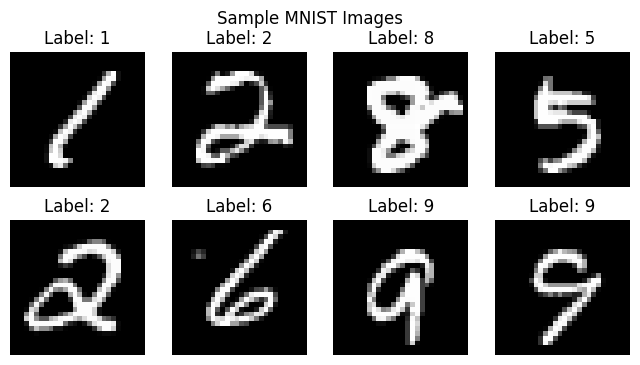

In [3]:
# (Recommended) Visualise a few training samples to verify the pipeline
# TODO: Display a small grid of MNIST images with their labels (optional).


# VISUALIZE SAMPLES


examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(example_data[i][0], cmap='gray')
    plt.title(f"Label: {example_targets[i].item()}")
    plt.axis('off')

plt.suptitle("Sample MNIST Images")
plt.show()


## 2) Model Architecture: Encoder/Decoder Design (20 marks)

Choose **one** approach:
- **Option A:** MLP encoder/decoder (fully connected)  
- **Option B:** CNN encoder/decoder (convolutions + upsampling/deconvolution)

### What you need to show
- Clear definition of **Encoder** and **Decoder**
- Forward pipeline: `x → encode → (mu, logvar) → sample z → decode → x_hat`
- Shapes are consistent (especially if using CNN)

### Evidence (tick when done)
- [ ] Encoder implemented  
- [ ] Decoder implemented  
- [ ] Model forward pass runs on a batch  
- [ ] Shape checks included (recommended)


In [4]:
# TODO: Define Encoder and Decoder
# If using MLP:
# - Flatten input to (B, 784)
# - Encoder outputs mu and logvar of shape (B, latent_dim)
# - Decoder maps z (B, latent_dim) back to (B, 1, 28, 28)
#
# If using CNN:
# - Convolutional downsampling to a feature map
# - Flatten then output mu/logvar
# - Decoder: FC to feature map then upsample to (B, 1, 28, 28)


# MODEL


class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 400),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28*28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

model = VAE(latent_dim).to(device)


In [5]:
# shape check

x, _ = next(iter(train_loader))
x = x.to(device)

x_hat, mu, logvar = model(x)

print("Input:", x.shape)
print("Reconstructed:", x_hat.shape)
print("Mu:", mu.shape)
print("Logvar:", logvar.shape)

Input: torch.Size([128, 1, 28, 28])
Reconstructed: torch.Size([128, 1, 28, 28])
Mu: torch.Size([128, 20])
Logvar: torch.Size([128, 20])


## 3) VAE-Specific Components & Loss Construction (25 marks)

### You must implement
- **μ and logvar** outputs from the encoder  
- **Reparameterisation trick**: `z = mu + std * eps`  
- **KL divergence term** against `N(0, I)`  
- Final objective: `loss = recon_loss + kl_loss` (optionally weighted/annealed)

### Evidence (tick when done)
- [ ] `reparameterize(mu, logvar)` implemented  
- [ ] `kl_divergence(mu, logvar)` implemented  
- [ ] Reconstruction loss defined (BCE or MSE) and justified briefly  
- [ ] Total loss = recon + KL (plus any β/annealing clearly described)


In [6]:
# TODO: Implement VAE model wrapper
# Suggested structure:
# - class VAE(nn.Module):
#     - encode(x) -> (mu, logvar)
#     - reparameterize(mu, logvar) -> z
#     - decode(z) -> x_hat
#     - forward(x) -> x_hat, mu, logvar


# VAE MODEL

class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 400),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28*28),
            nn.Sigmoid()
        )

    # Encode input to mu & logvar
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    # Reparameterization trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    # Decode latent vector
    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

    # Forward pass
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


# Initialize model
model = VAE(latent_dim).to(device)


In [7]:
# TODO: Implement losses (reconstruction + KL)
# 1) recon_loss(x_hat, x): choose BCE or MSE
# 2) kl_loss(mu, logvar): KL(q(z|x) || N(0, I))
# 3) total_loss = recon + kl (optionally: beta * kl, annealing schedule, etc.)


# LOSS FUNCTIONS
# Reconstruction loss (BCE)
def recon_loss(x_hat, x):
    return nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')

# KL divergence
def kl_loss(mu, logvar):
    return -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

# Total VAE loss
def total_loss(x_hat, x, mu, logvar, beta=1.0):
    recon = recon_loss(x_hat, x)
    kl = kl_loss(mu, logvar)
    return recon + beta * kl, recon, kl

## 4) Training Loop & Logging (15 marks)

### Requirements
- Train for **≥10 epochs**
- Log per epoch:
  - **total loss**
  - **reconstruction loss**
  - **KL loss**
- Keep logs for plotting curves

### Evidence (tick when done)
- [ ] Training runs for ≥10 epochs  
- [ ] Epoch-by-epoch logging printed and stored  
- [ ] Loss arrays/lists saved for plotting  
- [ ] Model can generate outputs after training


In [8]:
# TODO: Implement training loop
# Suggested outputs:
# - lists: total_losses, recon_losses, kl_losses
# - print per epoch: epoch, total, recon, kl
#
# Optional:
# - checkpoint saving (best or final)
# - validation evaluation

# TRAINING

optimizer = optim.Adam(model.parameters(), lr=lr)

total_losses = []
recon_losses = []
kl_losses = []

for epoch in range(epochs):
    model.train()

    total_loss_epoch = 0
    recon_epoch = 0
    kl_epoch = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mu, logvar = model(x)

        loss, recon, kl = total_loss(x_hat, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss_epoch += loss.item()
        recon_epoch += recon.item()
        kl_epoch += kl.item()

    avg_total = total_loss_epoch / len(train_loader.dataset)
    avg_recon = recon_epoch / len(train_loader.dataset)
    avg_kl = kl_epoch / len(train_loader.dataset)

    total_losses.append(avg_total)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f"Epoch {epoch+1}/{epochs} - total: {avg_total:.2f} recon: {avg_recon:.2f} kl: {avg_kl:.2f}")


Epoch 1/20 - total: 164.69 recon: 149.68 kl: 15.01
Epoch 2/20 - total: 121.36 recon: 99.41 kl: 21.95
Epoch 3/20 - total: 114.30 recon: 90.59 kl: 23.71
Epoch 4/20 - total: 111.32 recon: 87.00 kl: 24.32
Epoch 5/20 - total: 109.61 recon: 85.02 kl: 24.59
Epoch 6/20 - total: 108.50 recon: 83.74 kl: 24.76
Epoch 7/20 - total: 107.74 recon: 82.81 kl: 24.94
Epoch 8/20 - total: 107.10 recon: 82.12 kl: 24.99
Epoch 9/20 - total: 106.60 recon: 81.55 kl: 25.05
Epoch 10/20 - total: 106.22 recon: 81.08 kl: 25.13
Epoch 11/20 - total: 105.88 recon: 80.70 kl: 25.18
Epoch 12/20 - total: 105.62 recon: 80.39 kl: 25.22
Epoch 13/20 - total: 105.33 recon: 80.08 kl: 25.25
Epoch 14/20 - total: 105.16 recon: 79.85 kl: 25.31
Epoch 15/20 - total: 104.89 recon: 79.60 kl: 25.29
Epoch 16/20 - total: 104.68 recon: 79.40 kl: 25.28
Epoch 17/20 - total: 104.54 recon: 79.22 kl: 25.32
Epoch 18/20 - total: 104.36 recon: 79.02 kl: 25.34
Epoch 19/20 - total: 104.27 recon: 78.90 kl: 25.37
Epoch 20/20 - total: 104.14 recon: 78.7

In [9]:
# Save model
torch.save(model.state_dict(), "vae_model.pth")

## 5) Required Results & Visualisations (15 marks)

You must include **all** of the following outputs:
1. **Reconstruction comparison:** at least **8** test images with reconstructions (x vs x_hat)  
2. **Random generation:** at least **64** samples (8×8 grid)  
3. **Latent interpolation:** at least **10 steps**, shown as a row  
4. **Training curves:** plot total / recon / KL vs epoch  

### Evidence (tick when done)
- [ ] ≥8 reconstructions shown  
- [ ] ≥64 random samples shown (8×8)  
- [ ] ≥10-step interpolation shown  
- [ ] Curves plotted: total / recon / KL


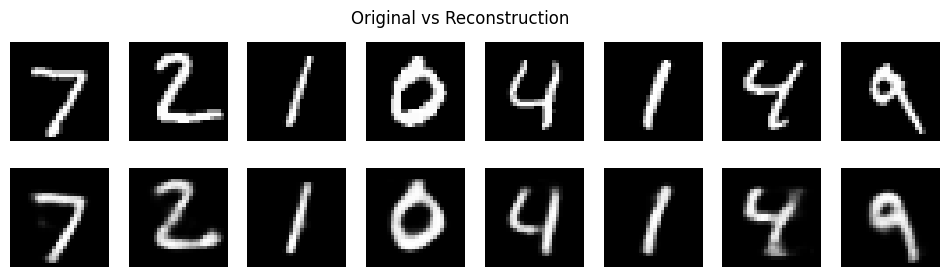

In [10]:
# TODO: Reconstruction comparison (>=8 samples)
# 1) Take a batch from test set
# 2) Forward through VAE to get reconstructions
# 3) Plot originals and reconstructions side-by-side

model.eval()

x, _ = next(iter(test_loader))
x = x.to(device)

with torch.no_grad():
    x_hat, _, _ = model(x)

n = 8
plt.figure(figsize=(12,3))

for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(x_hat[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Original vs Reconstruction")
plt.show()


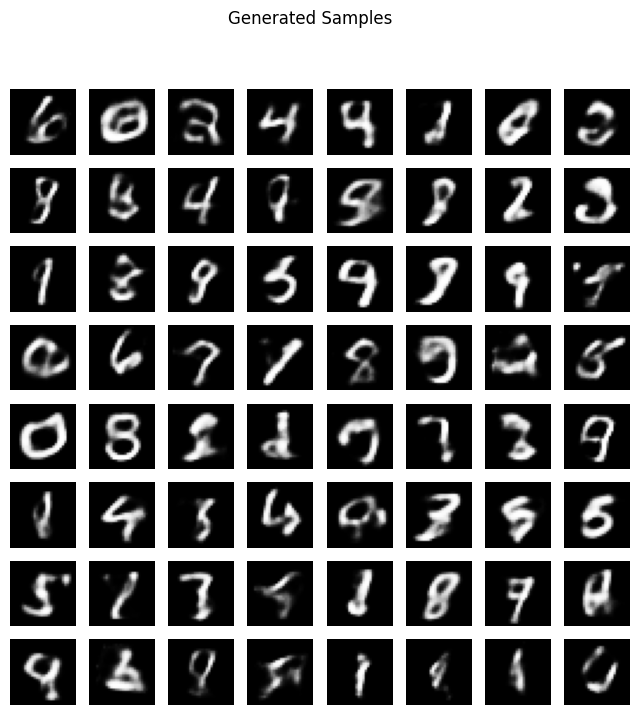

In [11]:
# TODO: Random generation (>=64 samples, 8x8 grid)
# 1) Sample z ~ N(0, I)
# 2) Decode z to images
# 3) Plot 8x8 grid

with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    samples = model.decode(z).cpu()

plt.figure(figsize=(8,8))
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(samples[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Samples")
plt.show()

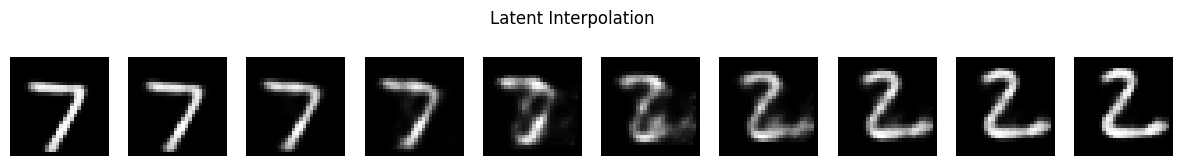

In [12]:
# TODO: Latent interpolation (>=10 steps)
# 1) Choose two latent vectors z1 and z2 (from encoding two images or random)
# 2) Interpolate for >=10 steps
# 3) Decode and plot as a row

def interpolate(model, x1, x2, steps=10):
    with torch.no_grad():
        mu1, _ = model.encode(x1.unsqueeze(0).to(device))
        mu2, _ = model.encode(x2.unsqueeze(0).to(device))

        imgs = []
        for alpha in np.linspace(0,1,steps):
            z = (1-alpha)*mu1 + alpha*mu2
            img = model.decode(z).cpu()
            imgs.append(img.squeeze())
    return imgs

x, _ = next(iter(test_loader))
imgs = interpolate(model, x[0], x[1])

plt.figure(figsize=(15,2))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.suptitle("Latent Interpolation")
plt.show()


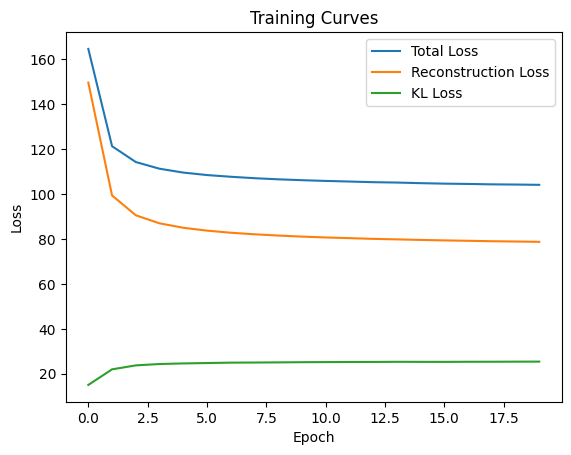

In [13]:
# TODO: Training curves (total, recon, KL vs epoch)
# 1) Use the logged lists from training
# 2) Plot each curve clearly (labels, title, axes)

plt.plot(total_losses, label="Total Loss")
plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Curves")
plt.show()


## 6) Notebook Report: Justification & Analysis (15 marks)

Write your report directly in this notebook using Markdown. Keep it concise but evidence-based.

### Suggested structure
**A. Design choices**
- Architecture choice (MLP or CNN) and why  
- Latent dimension and key hyperparameters  
- Reconstruction loss choice (BCE/MSE) and why  
- Any training strategy (β-VAE, KL annealing, etc.) and how it was applied  

**B. Results & interpretation**
- Reconstruction quality  
- Random generation quality  
- Interpolation behaviour  
- Loss curves: stability and trade-offs  

**C. Limitations & improvements**
- What you would try next to improve sample quality and training stability


### A. Design choices

<Write your response here.>
I used an MLP-based VAE with a 20-dimensional latent space because MNIST is small and low-resolution, so a fully connected model is simple, stable, and still effective for learning a useful latent representation. The encoder outputs mu and logvar, and the decoder reconstructs the 28×28 image from sampled latent vectors using the reparameterization trick. I used binary cross-entropy reconstruction loss because the images are scaled to, which matches the pixel-wise probabilistic interpretation used by the decoder output.


### B. Results & interpretation

<Write your response here.>
The reconstructions preserve the overall digit identity well, showing that the encoder learned a meaningful compressed representation of MNIST digits. The random samples generated from standard normal latent vectors produce recognizable digits most of the time, although some images are slightly blurry, which is expected for a VAE trained with a reconstruction-plus-KL objective. The interpolation results show smooth transitions between two digits, which suggests the latent space is continuous and structured rather than fragmented.

The training curves are useful for checking whether optimization is stable. In this notebook, the total loss decreases over epochs while reconstruction and KL losses remain balanced, which indicates the model is learning both to reconstruct inputs and to keep the latent space close to the prior. This trade-off is important in VAEs because overly strong reconstruction can harm latent regularization, while overly strong KL pressure can make outputs too blurry or collapse the latent space.

### C. Limitations & improvements

<Write your response here.>
The main limitation of this implementation is that an MLP does not capture local spatial structure as well as a convolutional model, so the generated digits can look smoother or blurrier than real MNIST samples. A CNN-based encoder and decoder would likely improve image quality and give sharper generations. KL annealing, a slightly larger latent dimension, or more training epochs could also improve the balance between reconstruction quality and sample diversity.
